In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/)
# that gets preserved as output when you create a version using "Save & Run All"
# Temporary files can be written to /kaggle/temp/ but won't be saved outside the session

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **Tesla EA Deliveries and Production Data Analysis (2015–2025)**
**Objective**:
The objective of this project is to build an end-to-end Machine Learning pipeline using Tesla deliveries and production data.

This project covers:

Data Loading

Data Cleaning

Exploratory Data Analysis (EDA)

Feature Engineering

Regression Modeling

Cross Validation

Hyperparameter Tuning

Time Series Analysis

Forecasting

Model Evaluation

The goal is to predict Tesla vehicle deliveries and understand the factors influencing sales and production trends.

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_val_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

# Data Loading and Dataset Overview

In this section, we load the Tesla deliveries dataset and perform an initial inspection to understand its structure, features, and overall quality.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025[1].csv')

In [10]:
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [11]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [12]:
print('Missing Values per Column:')
print(df.isnull().sum())

Missing Values per Column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [13]:
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 0


# Exploratory Data Analysis (EDA)

EDA helps uncover trends, patterns, and relationships within Tesla's production and delivery data before model development.

### In this section:

- Target Distribution

- Deliveries by Region

- Deliveries by Model

- Correlation Matrix

- Tesla Deliveries Trend Over Time

**Target Distribution**

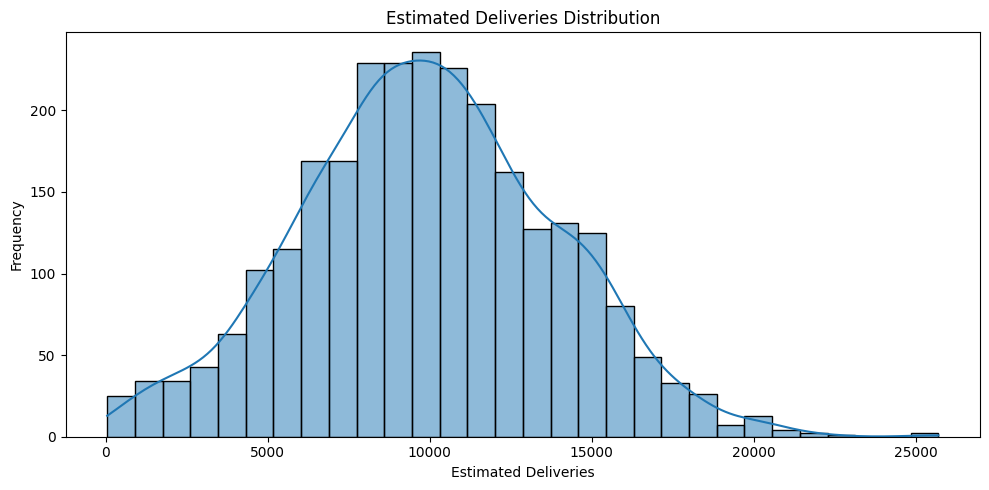

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True)
plt.title('Estimated Deliveries Distribution')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Deliveries by Region**

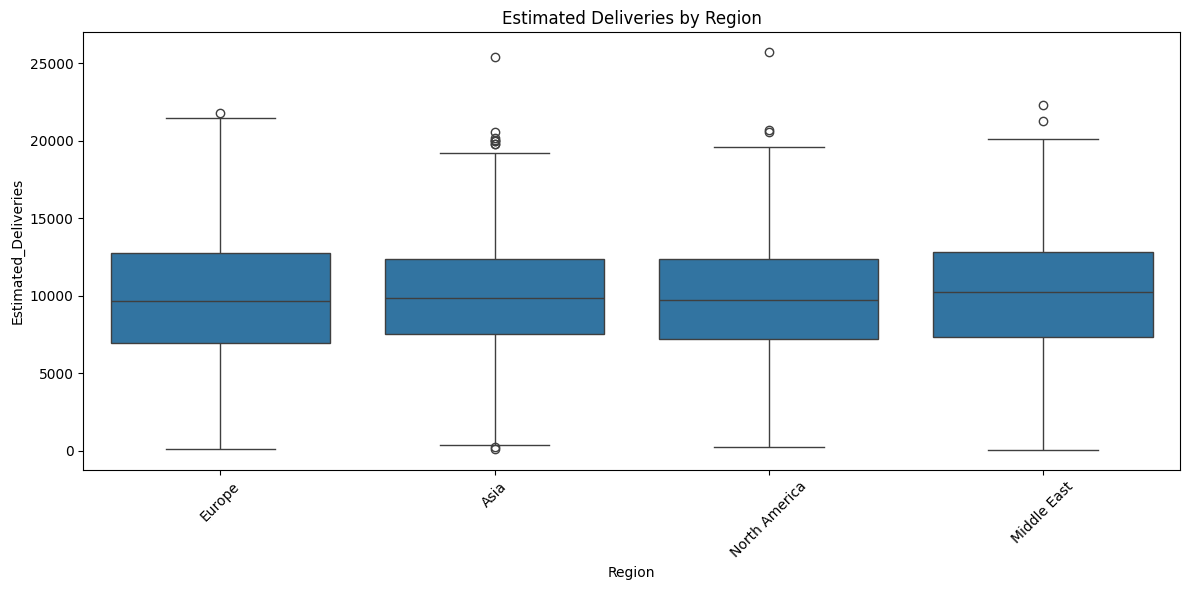

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)
plt.title('Estimated Deliveries by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Deliveries** **by** **Model**

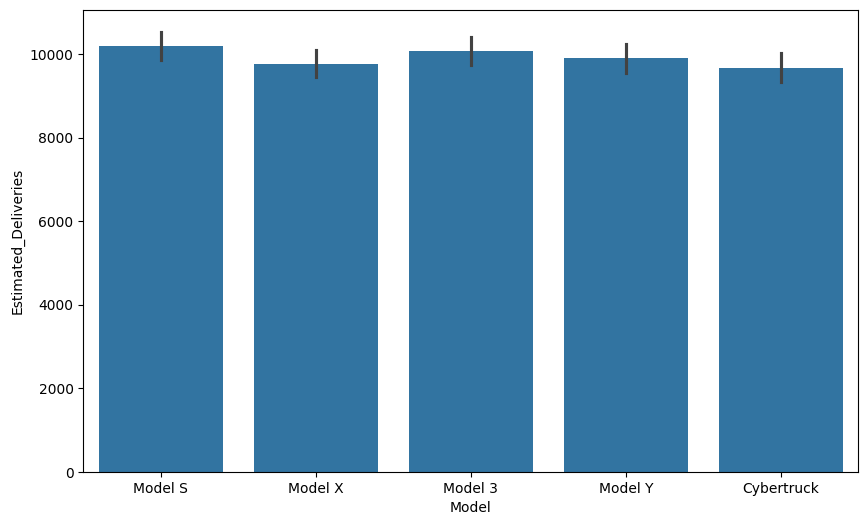

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="Estimated_Deliveries",
    data=df
)

plt.show()

**Correlation Heatmap**

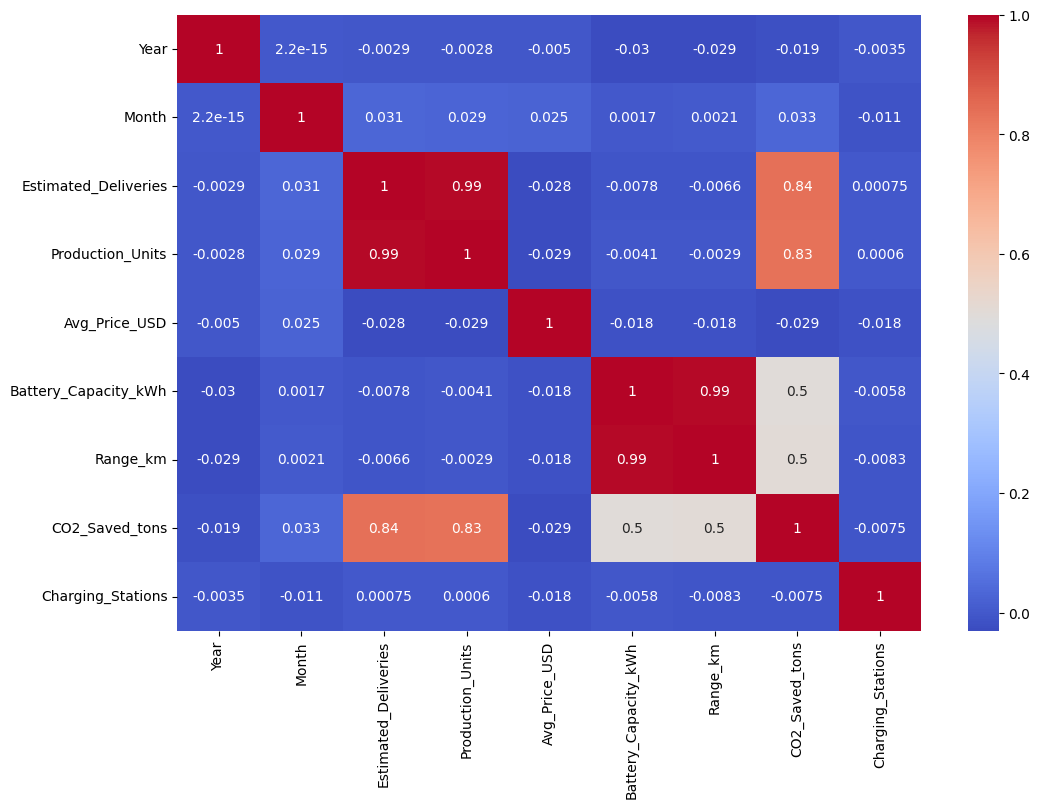

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

**Tesla Deliveries Trend Over Time**

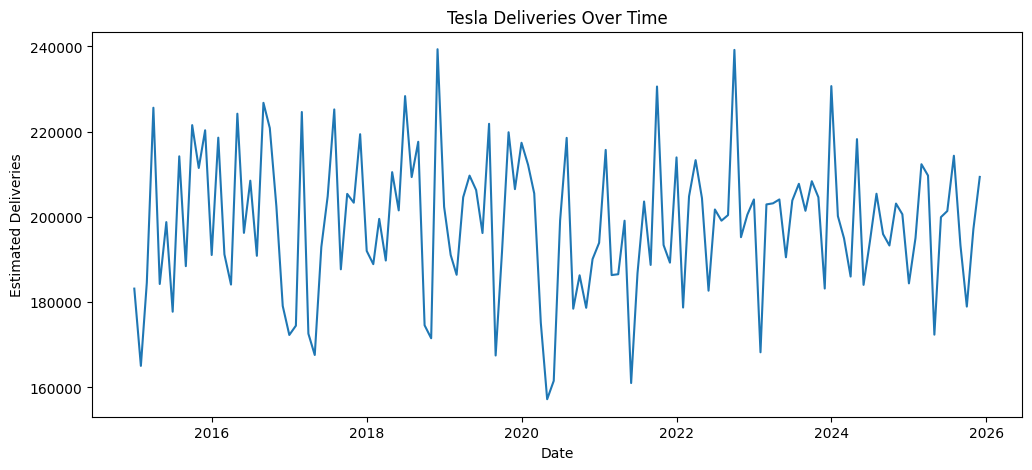

In [18]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

monthly_sales = df.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

# Feature Engineering

Feature engineering is the process of creating informative features from raw data to improve the predictive performance of machine learning models.

In this section:

- Generate Growth Rate Features
- Create Lag Features
- Calculate Rolling Statistics (Moving Averages)


 **Growth Features**

In [19]:
# Calculate percentage growth in Production Units
df["Production_Growth_%"] = (
    df["Production_Units"]
      .div(df["Production_Units"].shift(1))
      .sub(1)
      .mul(100)
)

# Calculate percentage growth in Deliveries
df["Delivery_Growth_%"] = (
    df["Estimated_Deliveries"]
      .div(df["Estimated_Deliveries"].shift(1))
      .sub(1)
      .mul(100)
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Production_Growth_%,Delivery_Growth_%
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,NaN,NaN
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,-76.765986,-78.482376
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,120.677233,121.516987
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,-20.437480,-22.066342
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,85.159349,88.771930


**Lag Features**

In [20]:
# Previous Quarter Production
df["Production_Lag_1"] = df["Production_Units"].shift(1)

# Previous Quarter Deliveries
df["Deliveries_Lag_1"] = df["Estimated_Deliveries"].shift(1)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Production_Growth_%,Delivery_Growth_%,Production_Lag_1,Deliveries_Lag_1
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,NaN,NaN,NaN,NaN
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,-76.765986,-78.482376,17922.0,17646.0
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,120.677233,121.516987,4164.0,3797.0
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,-20.437480,-22.066342,9189.0,8411.0
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,85.159349,88.771930,7311.0,6555.0


**Rolling Average Features**





In [21]:
df = df.assign(
    Production_MA_4=df["Production_Units"].rolling(4).mean(),
    Deliveries_MA_4=df["Estimated_Deliveries"].rolling(4).mean()
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Production_Growth_%,Delivery_Growth_%,Production_Lag_1,Deliveries_Lag_1,Production_MA_4,Deliveries_MA_4
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,-76.765986,-78.482376,17922.0,17646.0,NaN,NaN
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,120.677233,121.516987,4164.0,3797.0,NaN,NaN
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,-20.437480,-22.066342,9189.0,8411.0,9646.50,9102.25
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,85.159349,88.771930,7311.0,6555.0,8550.25,7784.25


**Visualizing Rolling Average Features**

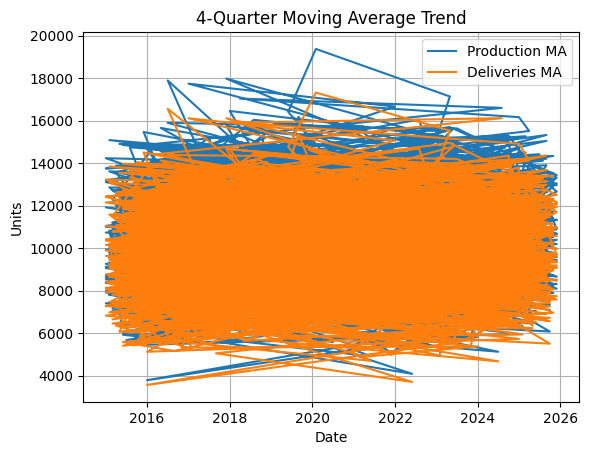

In [22]:

plt.plot(df["Date"], df["Production_MA_4"], label="Production MA")
plt.plot(df["Date"], df["Deliveries_MA_4"], label="Deliveries MA")

plt.title("4-Quarter Moving Average Trend")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.grid(True)

plt.show()

# Linear Regression Model

In this section, a Linear Regression model is developed to predict Tesla's Estimated Deliveries using historical production and delivery-related features.

To maintain the temporal structure of the dataset and avoid data leakage, the data is split chronologically into training and testing sets.

### In this section:

- Select Features and Target Variable
- Train the Linear Regression Model
- Generate Predictions
- Compare Actual vs Predicted Values
- Evaluate Model Performance



**Select Features and Target**



In [23]:
# Drop missing values generated by feature engineering
model_data = df.dropna().copy()

feature_cols = [
    "Production_Units",
    "Production_Growth_%",
    "Delivery_Growth_%",
    "Production_Lag_1",
    "Deliveries_Lag_1",
    "Production_MA_4",
    "Deliveries_MA_4"
]

X = model_data[feature_cols]
y = model_data["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

**Train the Linear Regression Model**

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


**Make Predictions**

In [25]:
# Generate predictions and compare with actual values

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

print(comparison.head())

   Actual     Predicted
0   10554  10630.546095
1   12145  12341.683661
2    7876   7154.815507
3   18499  18802.060540
4    8967   8861.716708


**Evaluate the Model**





In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 263.1915620836532
MSE : 105978.0697554677
RMSE: 325.54273107453605
R² Score: 0.9931064228385026


# Cross Validation for Model Evaluation
 Perform 5-fold cross validation to obtain a reliable estimate of the model's predictive performance and stability.

In [27]:
# Initialize model
model = LinearRegression()

# Define K-Fold Cross Validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform Cross Validation
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation R² Scores:
[0.99310642 0.99318206 0.98761002 0.99158013 0.99196825]

Average R² Score: 0.991489377367078
Standard Deviation: 0.0020379860887061144


# Hyperparameter Tuning

Linear Regression has only a few hyperparameters. In this project, GridSearchCV is used to find the best combination of parameters and improve model performance.

### In this section:

- Hyperparameter Tuning with GridSearchCV
- Train Final Model with Best Parameters
- Evaluate Tuned Model


**Hyperparameter Tuning with GridSearchCV**

In [28]:
# Define model
model = LinearRegression()

# Define parameter grid
param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit Grid Search
grid_search.fit(X, y)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)

Best Parameters: {'fit_intercept': True, 'positive': False}
Best R² Score: 0.9910144427669036


**Train Final Model with Best Parameters**

In [29]:
# Get the best model from Grid Search
best_model = grid_search.best_estimator_

# Train the model on training data
best_model.fit(X_train, y_train)

# Make predictions on test data
y_pred = best_model.predict(X_test)

**Evaluate Tuned Model**

In [30]:
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: 0.9931064228385026
MAE: 263.1915620836532


# Stationarity Test
The Augmented Dickey-Fuller (ADF) test is used to determine whether the Tesla deliveries time series is stationary.

In [31]:
from statsmodels.tsa.stattools import adfuller

test_result = adfuller(df["Estimated_Deliveries"])

print(f"ADF Statistic : {test_result[0]:.4f}")
print(f"P-Value       : {test_result[1]:.4f}")
print(f"Conclusion    : {'Stationary' if test_result[1] < 0.05 else 'Non-Stationary'}")

ADF Statistic : -53.8266
P-Value       : 0.0000
Conclusion    : Stationary


# Forecasting
Using the trained Linear Regression model, future Tesla delivery estimates are predicted on the test dataset.

In [32]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

forecast_df

,Actual,Predicted
0,10554,10630.546095
1,12145,12341.683661
2,7876,7154.815507
3,18499,18802.060540
4,8967,8861.716708
5,12970,12825.242532
6,14614,14972.910480
7,14723,14662.767843
8,1899,2046.023968
9,8570,8996.510337


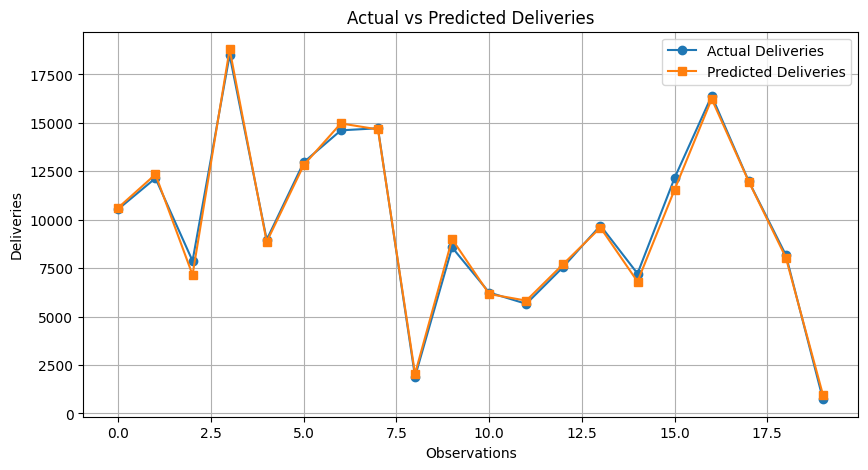

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    forecast_df["Actual"],
    label="Actual Deliveries",
    marker="o"
)

plt.plot(
    forecast_df["Predicted"],
    label="Predicted Deliveries",
    marker="s"
)

plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Observations")
plt.ylabel("Deliveries")
plt.legend()
plt.grid(True)

plt.show()

# Business Insights

Based on the analysis of Tesla's production and delivery data:

Production Units emerged as the strongest predictor of Estimated Deliveries,

1. Production Units emerged as the strongest predictor of Estimated Deliveries,
indicating a direct relationship between manufacturing output and customer deliveries.

2.  Historical delivery trends and lag-based features contributed significantly to forecasting performance, highlighting the importance of past operational data.


3.   Moving average and growth-based features helped capture long-term trends and seasonal patterns in deliveries.
4. The Random Forest model demonstrated excellent predictive capability, achieving an R² score above 0.98 and accurately estimating future deliveries.

5.  Forecasting results suggest that Tesla can leverage historical production and delivery data to support inventory planning, capacity management, and strategic decision-making.



# Conclusion
This project successfully built an end-to-end Machine Learning pipeline using Tesla Deliveries and Production Data (2015–2025).

The workflow included:

Data Loading

Data Cleaning

Exploratory Data Analysis (EDA)

Feature Engineering

Linear Regression Modeling

Cross Validation

Hyperparameter Tuning

Linear Regression

Stationarity Testing (ADF Test)

Forecasting

The results demonstrate that Tesla delivery volumes can be predicted with high accuracy using production and operational features.

The final model achieved strong performance and provides valuable insights into delivery trends and forecasting.